In [1]:
import pandas as pd
import os
import scanpy as sc
import anndata as ad
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import shutil
import muon as mu
import scirpy as ir
import anndata
from tqdm import tqdm
from scipy.stats import entropy
import matplotlib.patches as mpatches
import sys
import os

/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packag

# Load data

In [2]:
adata_filt = sc.read_h5ad('/home/jupyter/data/ge_korea/results/tcr_analysis/mvtcr_adata_new_correct_progression.h5ad')

In [12]:
adata_filt.obs['progression'] = adata_filt.obs['patient'].map({
 'E30': 'Fast',
 'E26': 'Slow',
 'E15': 'Slow',
 'E21': 'Slow',
 'E43': 'Fast',
 'E37': 'Slow',
 'E14': 'Fast',
 'E44': 'Fast',
 'E36': 'Slow',
 'E42': 'Slow',
 'E31': 'Fast',
 'E17': 'Slow',
 'E38': 'Slow',
 'E16': 'Fast',
 'E24': 'Slow',
 'E22': 'Fast',
 'E45': 'Fast',
 'E35': 'Slow',
 'E33': 'Slow',
 'E27': 'Fast',
 'E23': 'Slow',
 'E34': 'Fast',
 'E39': 'Slow',
 'E25': 'Fast',
 'E41': 'Slow',
 'E12': 'Fast',
 'E18': 'Slow',
 'E20': 'Slow',
 'E32': 'Fast',
 'E46': 'Fast',
 'E40': 'Slow',
 'E29': 'Slow',
 'E19': 'Fast'})

In [15]:
adata_filt.obs['annot_final'].value_counts()

GZMK+ CD8 T progenitor ex Cell    18794
T naive/early memory Cell         11080
Treg                               9905
Tactiv Cell                        8695
CD8 Tem Cell                       6819
Terminal CD8 Tex Cell              2542
CD8 HSP T cell                     2297
Tprolif Cell                       1854
Th17/Tc17                          1630
Th17                               1122
CD8 Cytotoxic T Cell                948
Tc17                                847
gd T Cell                           235
NKT                                  45
Name: annot_final, dtype: int64

In [16]:
#scales_counts = sc.pp.normalize_total(adata_filt, target_sum=None, inplace=False)
# log1p transform
#adata_filt.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)
#adata_filt.X = adata_filt.layers['log1p_norm']

In [17]:
adata_filt_bl = adata_filt[adata_filt.obs['timepoint'] == 'B']
adata_filt_f1 = adata_filt[adata_filt.obs['timepoint'] == 'F1']
adata_filt_f2 = adata_filt[adata_filt.obs['timepoint'] == 'F2']

In [18]:
adata_filt_blf1 = adata_filt[(
    adata_filt.obs['clonotype'].isin(adata_filt_bl.obs['clonotype'].unique())) &  (
        adata_filt.obs['clonotype'].isin(adata_filt_f1.obs['clonotype'].unique()))]
adata_filt_f1f2 = adata_filt[(
    adata_filt.obs['clonotype'].isin(adata_filt_f1.obs['clonotype'].unique())) &  (
        adata_filt.obs['clonotype'].isin(adata_filt_f2.obs['clonotype'].unique()))]

In [19]:
adata_filt.obs['annot_final'].value_counts()

GZMK+ CD8 T progenitor ex Cell    18794
T naive/early memory Cell         11080
Treg                               9905
Tactiv Cell                        8695
CD8 Tem Cell                       6819
Terminal CD8 Tex Cell              2542
CD8 HSP T cell                     2297
Tprolif Cell                       1854
Th17/Tc17                          1630
Th17                               1122
CD8 Cytotoxic T Cell                948
Tc17                                847
gd T Cell                           235
NKT                                  45
Name: annot_final, dtype: int64

In [20]:
adata_filt_blf1_cd4 = adata_filt[(
    adata_filt.obs['clonotype'].isin(adata_filt_bl.obs['clonotype'].unique())) &  (
        adata_filt.obs['clonotype'].isin(adata_filt_f1.obs['clonotype'].unique())) & (
        adata_filt.obs['annot_final'].isin(['CD4 T naive/early memory Cell','Treg','Tactiv Cell',
                                           'Tprolif Cell','Th17/Tc17','Th17',
                                            'T naive/early memory Cell','Tnaive Cell']))]
adata_filt_f1f2_cd4 = adata_filt[(
    adata_filt.obs['clonotype'].isin(adata_filt_f1.obs['clonotype'].unique())) &  (
        adata_filt.obs['clonotype'].isin(adata_filt_f2.obs['clonotype'].unique())) & (
        adata_filt.obs['annot_final'].isin(['CD4 T naive/early memory Cell','Treg','Tactiv Cell',
                                           'Tprolif Cell','Th17/Tc17','Th17',
                                            'T naive/early memory Cell','Tnaive Cell']))]

In [21]:
adata_filt_blf1_cd8 = adata_filt[(
    adata_filt.obs['clonotype'].isin(adata_filt_bl.obs['clonotype'].unique())) &  (
        adata_filt.obs['clonotype'].isin(adata_filt_f1.obs['clonotype'].unique())) & (
        adata_filt.obs['annot_final'].isin(['GZMK+ CD8 T progrenitor ex Cell','Tactiv Cell',
                                           'CD8 Tem Cell','Terminal CD8 Tex Cell','CD8 HSP T cell',
                                           'Tprolif Cell','Th17/Tc17','CD8 T naive/early memory Cell',
                                           'CD8 Cytotoxic T Cell','Tc17','T naive/early memory Cell',
                                           'Tnaive Cell']))]
adata_filt_f1f2_cd8 = adata_filt[(
    adata_filt.obs['clonotype'].isin(adata_filt_f1.obs['clonotype'].unique())) &  (
        adata_filt.obs['clonotype'].isin(adata_filt_f2.obs['clonotype'].unique())) & (
        adata_filt.obs['annot_final'].isin(['GZMK+ CD8 T progrenitor ex Cell','Tactiv Cell',
                                           'CD8 Tem Cell','Terminal CD8 Tex Cell','CD8 HSP T cell',
                                           'Tprolif Cell','Th17/Tc17','CD8 T naive/early memory Cell',
                                           'CD8 Cytotoxic T Cell','Tc17','T naive/early memory Cell',
                                           'Tnaive Cell']))]

In [22]:
sys.path.append(os.path.abspath("/home/jupyter/data/ge_korea/notebooks_2024/tcr_analysis"))
import alluvial

In [23]:
color_dict = {
    'T naive/early memory Cell' : '#1f77b4',
    'GZMK+ CD8 T progenitor ex Cell' : '#aec7e8',
    'CD8 Tem Cell' : '#ff7f0e',
    'Tactiv Cell' : '#ffbb78',
    'CD8 HSP T cell' : '#98df8a',
    'CD8 T naive/early memory Cell' : '#d62728',
    'CD4 T naive/early memory Cell' : '#ff9896',
    'CD8 Cytotoxic T Cell' : '#9467bd',
    'Tprolif Cell' : '#8c564b',
    'Treg' : '#c49c94',
    'Tc17' : '#e377c2',
    'Terminal CD8 Tex Cell' : '#f7b6d2',
    'Th17/Tc17' : '#c7c7c7',
    'gd T Cell' : '#bcbd22',
    'NKT' : '#dbdb8d',
    'Th17' : '#17becf',
    'Tnaive Cell' : '#9edae5'
}

In [24]:
temp = adata_filt.copy()
#temp.obs['annot_final'] = temp.obs['annot_final'].replace('GZMK+ CD8 T progrenitor ex Cell','GZMK+ CD8 T progenitor ex Cell')

In [25]:
temp.obs['timepoint_progression'] = temp.obs['timepoint'].astype(str) + '_' + temp.obs['progression'].astype(str)

In [26]:
counts_by_sample = pd.read_csv('/home/jupyter/data/ge_korea/results/tcr_analysis/cell_counts_by_sample.csv')

In [27]:
temp.obs['patient_clonotype'] = temp.obs['patient'].astype(str) + '_' + temp.obs['clonotype'].astype(str)

In [28]:
temp_dict = {}
b_fast = []
for i in temp[temp.obs['timepoint_progression'] == 'B_Fast'].obs['sample_x'].unique():
    temp_temp = temp[temp.obs['sample_x'] == i]
    proportions = temp_temp[temp_temp.obs['timepoint_progression'] == 'B_Fast'].obs['annot_final'].value_counts().div(temp_temp[temp_temp.obs['timepoint_progression'] == 'B_Fast'].obs[['annot_final','patient_clonotype']].drop_duplicates()['annot_final'].value_counts())
    #proportions = proportions / counts_by_sample[counts_by_sample['Sample'] == i]['Total'].iloc[0]
    b_fast.append(proportions)
b_slow = []
for i in temp[temp.obs['timepoint_progression'] == 'B_Slow'].obs['sample_x'].unique():
    temp_temp = temp[temp.obs['sample_x'] == i]
    proportions = temp_temp[temp_temp.obs['timepoint_progression'] == 'B_Slow'].obs['annot_final'].value_counts().div(temp_temp[temp_temp.obs['timepoint_progression'] == 'B_Slow'].obs[['annot_final','patient_clonotype']].drop_duplicates()['annot_final'].value_counts())
    #proportions = proportions / counts_by_sample[counts_by_sample['Sample'] == i]['Total'].iloc[0]
    b_slow.append(proportions)
f1_fast = []
for i in temp[temp.obs['timepoint_progression'] == 'F1_Fast'].obs['sample_x'].unique():
    temp_temp = temp[temp.obs['sample_x'] == i]
    proportions = temp_temp[temp_temp.obs['timepoint_progression'] == 'F1_Fast'].obs['annot_final'].value_counts().div(temp_temp[temp_temp.obs['timepoint_progression'] == 'F1_Fast'].obs[['annot_final','patient_clonotype']].drop_duplicates()['annot_final'].value_counts())
    #proportions = proportions / counts_by_sample[counts_by_sample['Sample'] == i]['Total'].iloc[0]
    f1_fast.append(proportions)
f1_slow = []
for i in temp[temp.obs['timepoint_progression'] == 'F1_Slow'].obs['sample_x'].unique():
    temp_temp = temp[temp.obs['sample_x'] == i]
    proportions = temp_temp[temp_temp.obs['timepoint_progression'] == 'F1_Slow'].obs['annot_final'].value_counts().div(temp_temp[temp_temp.obs['timepoint_progression'] == 'F1_Slow'].obs[['annot_final','patient_clonotype']].drop_duplicates()['annot_final'].value_counts())
    #proportions = proportions / counts_by_sample[counts_by_sample['Sample'] == i]['Total'].iloc[0]
    f1_slow.append(proportions)
f2_fast = []
for i in temp[temp.obs['timepoint_progression'] == 'F2_Fast'].obs['sample_x'].unique():
    temp_temp = temp[temp.obs['sample_x'] == i]
    proportions = temp_temp[temp_temp.obs['timepoint_progression'] == 'F2_Fast'].obs['annot_final'].value_counts().div(temp_temp[temp_temp.obs['timepoint_progression'] == 'F2_Fast'].obs[['annot_final','patient_clonotype']].drop_duplicates()['annot_final'].value_counts())
    #proportions = proportions / counts_by_sample[counts_by_sample['Sample'] == i]['Total'].iloc[0]
    f2_fast.append(proportions)
f2_slow = []
for i in temp[temp.obs['timepoint_progression'] == 'F2_Slow'].obs['sample_x'].unique():
    temp_temp = temp[temp.obs['sample_x'] == i]
    proportions = temp_temp[temp_temp.obs['timepoint_progression'] == 'F2_Slow'].obs['annot_final'].value_counts().div(temp_temp[temp_temp.obs['timepoint_progression'] == 'F2_Slow'].obs[['annot_final','patient_clonotype']].drop_duplicates()['annot_final'].value_counts())
    #proportions = proportions / counts_by_sample[counts_by_sample['Sample'] == i]['Total'].iloc[0]
    f2_slow.append(proportions)
temp_dict['B_Fast'] = pd.DataFrame(b_fast).mean(axis=0)
temp_dict['B_Slow'] = pd.DataFrame(b_slow).mean(axis=0)
temp_dict['F1_Fast'] = pd.DataFrame(f1_fast).mean(axis=0)
temp_dict['F1_Slow'] = pd.DataFrame(f1_slow).mean(axis=0)
temp_dict['F2_Fast'] = pd.DataFrame(f2_fast).mean(axis=0)
temp_dict['F2_Slow'] = pd.DataFrame(f2_slow).mean(axis=0)

In [29]:
temp_df = pd.DataFrame(temp_dict).sort_values(by='B_Fast')
temp_df_old = temp_df.copy()
temp_df = pd.DataFrame({'B Slow - B Fast' : temp_df['B_Slow'] - temp_df['B_Fast'],
                        'F1 Slow - F1 Fast' : temp_df['F1_Slow'] - temp_df['F1_Fast'],
                        'F2 Slow - F2 Fast' : temp_df['F2_Slow'] - temp_df['F2_Fast']}).T

/tmp/ipykernel_1491/2553184155.py:1: UserWarning: 'color' and 'colormap' cannot be used simultaneously. Using 'color'
  ax = temp_df.plot(kind='bar',stacked=True,colormap='tab20',title='Cells / Clonotype\n(Slow - Fast at each timepoint)',color=color_dict)


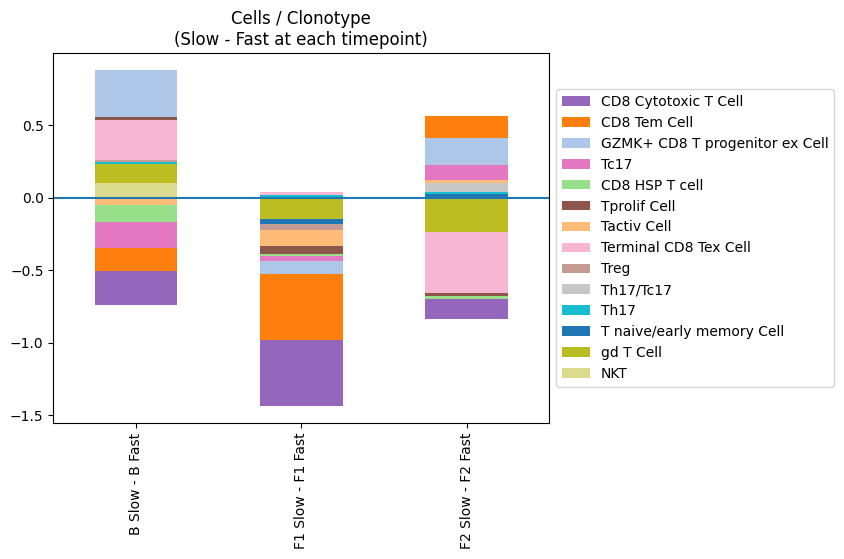

In [30]:
ax = temp_df.plot(kind='bar',stacked=True,colormap='tab20',title='Cells / Clonotype\n(Slow - Fast at each timepoint)',color=color_dict)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1],loc='center left', bbox_to_anchor=(1, 0.5))
ax.axhline(0)

In [31]:
#temp_df_old = temp_df_old.loc[['CD8 Tem Cell','Tprolif Cell','Tactiv Cell','GZMK+ CD8 T progenitor ex Cell',
#'Terminal CD8 Tex Cell','Tc17']]

#['CD8 Tem','Tprolif Cell','Tactiv Cell','GZMK+ CD8 T progrenitor ex Cell',
#'Terminal CD8 Tex Cell']

In [32]:
temp_df_old

,B_Fast,B_Slow,F1_Fast,F1_Slow,F2_Fast,F2_Slow
NKT,1.000000,1.100000,1.000000,1.000000,1.000000,1.000000
gd T Cell,1.028571,1.158974,1.232993,1.085714,1.287879,1.053140
T naive/early memory Cell,1.035906,1.030089,1.058219,1.024033,1.007416,1.036445
Th17,1.041679,1.058212,1.008801,1.024731,1.029545,1.040976
Th17/Tc17,1.049158,1.046058,1.021154,1.027714,1.002326,1.064413
Treg,1.071721,1.088714,1.091679,1.051343,1.039159,1.035442
Terminal CD8 Tex Cell,1.110000,1.385221,1.806215,1.822090,1.976420,1.558623
Tactiv Cell,1.129325,1.087373,1.184109,1.076066,1.164404,1.186032
Tprolif Cell,1.143221,1.164330,1.262700,1.201541,1.253513,1.232491
CD8 HSP T cell,1.235743,1.122133,1.072650,1.062130,1.160298,1.137379


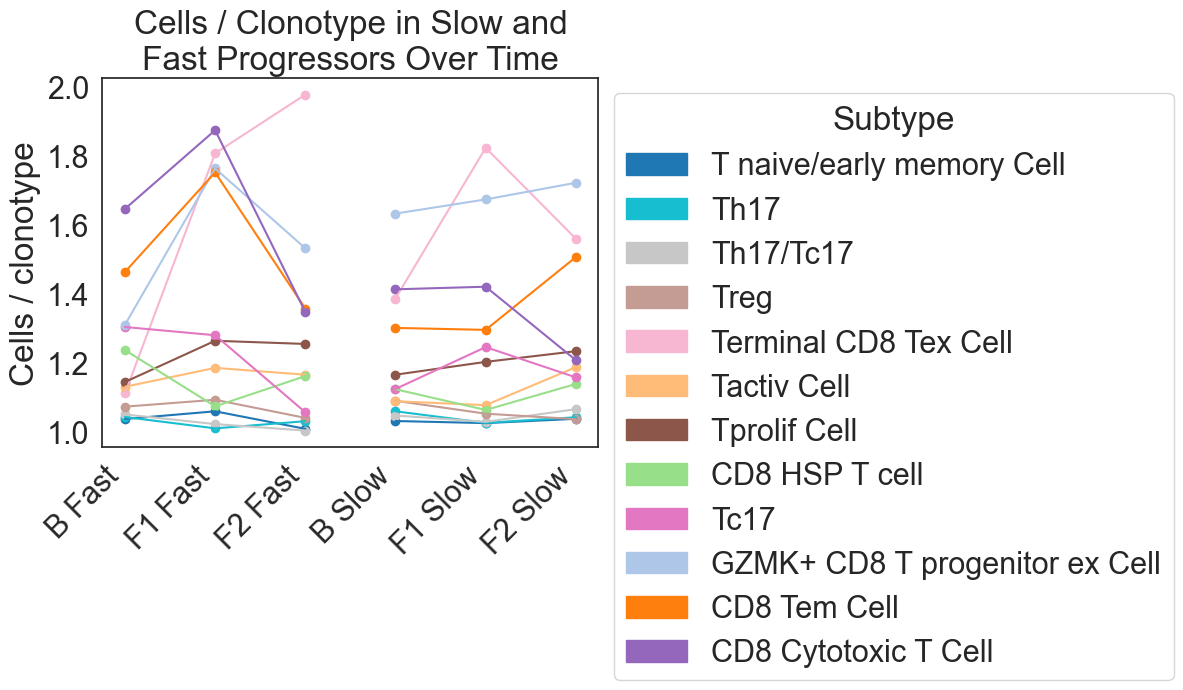

In [33]:
sns.set(font_scale=2)
sns.set_style('white')
patches = []
for i in temp_df_old.index.tolist():
    if i == 'NKT' or i == 'gd T Cell':
        continue
    else:
        plt.scatter([1,2,3],[temp_df_old.loc[i,'B_Fast'],temp_df_old.loc[i,'F1_Fast'],
         temp_df_old.loc[i,'F2_Fast']],c=color_dict[i])
        plt.plot([1,2,3],[temp_df_old.loc[i,'B_Fast'],temp_df_old.loc[i,'F1_Fast'],
         temp_df_old.loc[i,'F2_Fast']],c=color_dict[i])
        
        plt.scatter([4,5,6],[temp_df_old.loc[i,'B_Slow'],temp_df_old.loc[i,'F1_Slow'],
         temp_df_old.loc[i,'F2_Slow']],c=color_dict[i])
        plt.plot([4,5,6],[temp_df_old.loc[i,'B_Slow'],temp_df_old.loc[i,'F1_Slow'],
         temp_df_old.loc[i,'F2_Slow']],c=color_dict[i])
    
    patches.append(mpatches.Patch(color=color_dict[i], label=i))

plt.legend(handles=patches,bbox_to_anchor=(1,1),title='Subtype')

plt.xticks([1,2,3,4,5,6], ['B Fast', 'F1 Fast', 'F2 Fast',
                           'B Slow', 'F1 Slow', 'F2 Slow'],rotation=45,ha='right')
plt.title('Cells / Clonotype in Slow and\nFast Progressors Over Time')
plt.ylabel('Cells / clonotype')
plt.show()